# Robustness and Uncertainty Appendix

## tl;dr

- GLD remains the highest-return asset in **Tightening across all six threshold scenarios**.
- GLD's Elevated-risk lead is **not stable** when VIX thresholds move from 20/30 to 25/35.
- The Stress sample ranges from **8 to 62 days**, demonstrating that Stress estimates are highly threshold-sensitive.
- Only **Calm / easing GLD, Elevated risk GLD** have 95% block-bootstrap annualized-return intervals that exclude zero.

These results support a narrower conclusion than the point estimates alone: gold's Tightening result is directionally robust, while most other regime-return claims remain uncertain.

## Context & Methods

### Threshold sensitivity

The appendix evaluates all six combinations of:

- VIX Elevated/Stress boundaries: **20/30** and **25/35**
- 63-trading-day DGS10 change: **0.25, 0.50, and 0.75 percentage points**

Every scenario keeps the one-trading-day signal lag, priority order, data window, and metric definitions fixed. The baseline is VIX 20/30 and +0.50pp.

### Sampling uncertainty

Annualized mean daily returns use 5,000 deterministic circular moving-block bootstrap samples with five-trading-day blocks. The blocks preserve short-run dependence better than an independent daily bootstrap. Intervals are descriptive sampling ranges, not forecasts, and do not solve threshold-selection uncertainty.

### Key assumptions

- Prices are distribution-adjusted with yfinance `auto_adjust=True`.
- Threshold scenarios are pre-declared and are not optimized against returns.
- Stress observations are clustered and scarce; the VIX 35 definition leaves only eight days.

## Data

Inputs are the versioned `data/processed/daily_asset_returns.csv` rows produced by the main pipeline. Outputs are saved in `data/processed/` and `outputs/figures/`.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.robustness_analysis import run_robustness_analysis

pd.set_option('display.max_columns', 20)
results = run_robustness_analysis(PROJECT_ROOT)
PROJECT_ROOT

WindowsPath('C:/Users/wldbs/OneDrive/바탕화면/Works/project3')

## Results

### Threshold sensitivity

In [2]:
results['robustness_summary']

,scenario,vix_elevated,vix_stress,yield_tightening_pp,is_baseline,classified_days,gld_leads_tightening,gld_leads_elevated_risk,ief_tightening_return_negative,stress_spy_return_positive,stress_observations
0,VIX 20/30; yield 0.25pp,20.0,30.0,0.25,False,1111,True,True,False,True,62
1,VIX 20/30; yield 0.50pp,20.0,30.0,0.50,True,1111,True,True,True,True,62
2,VIX 20/30; yield 0.75pp,20.0,30.0,0.75,False,1111,True,True,True,True,62
3,VIX 25/35; yield 0.25pp,25.0,35.0,0.25,False,1111,True,False,False,True,8
4,VIX 25/35; yield 0.50pp,25.0,35.0,0.50,False,1111,True,False,True,True,8
5,VIX 25/35; yield 0.75pp,25.0,35.0,0.75,False,1111,True,False,True,True,8


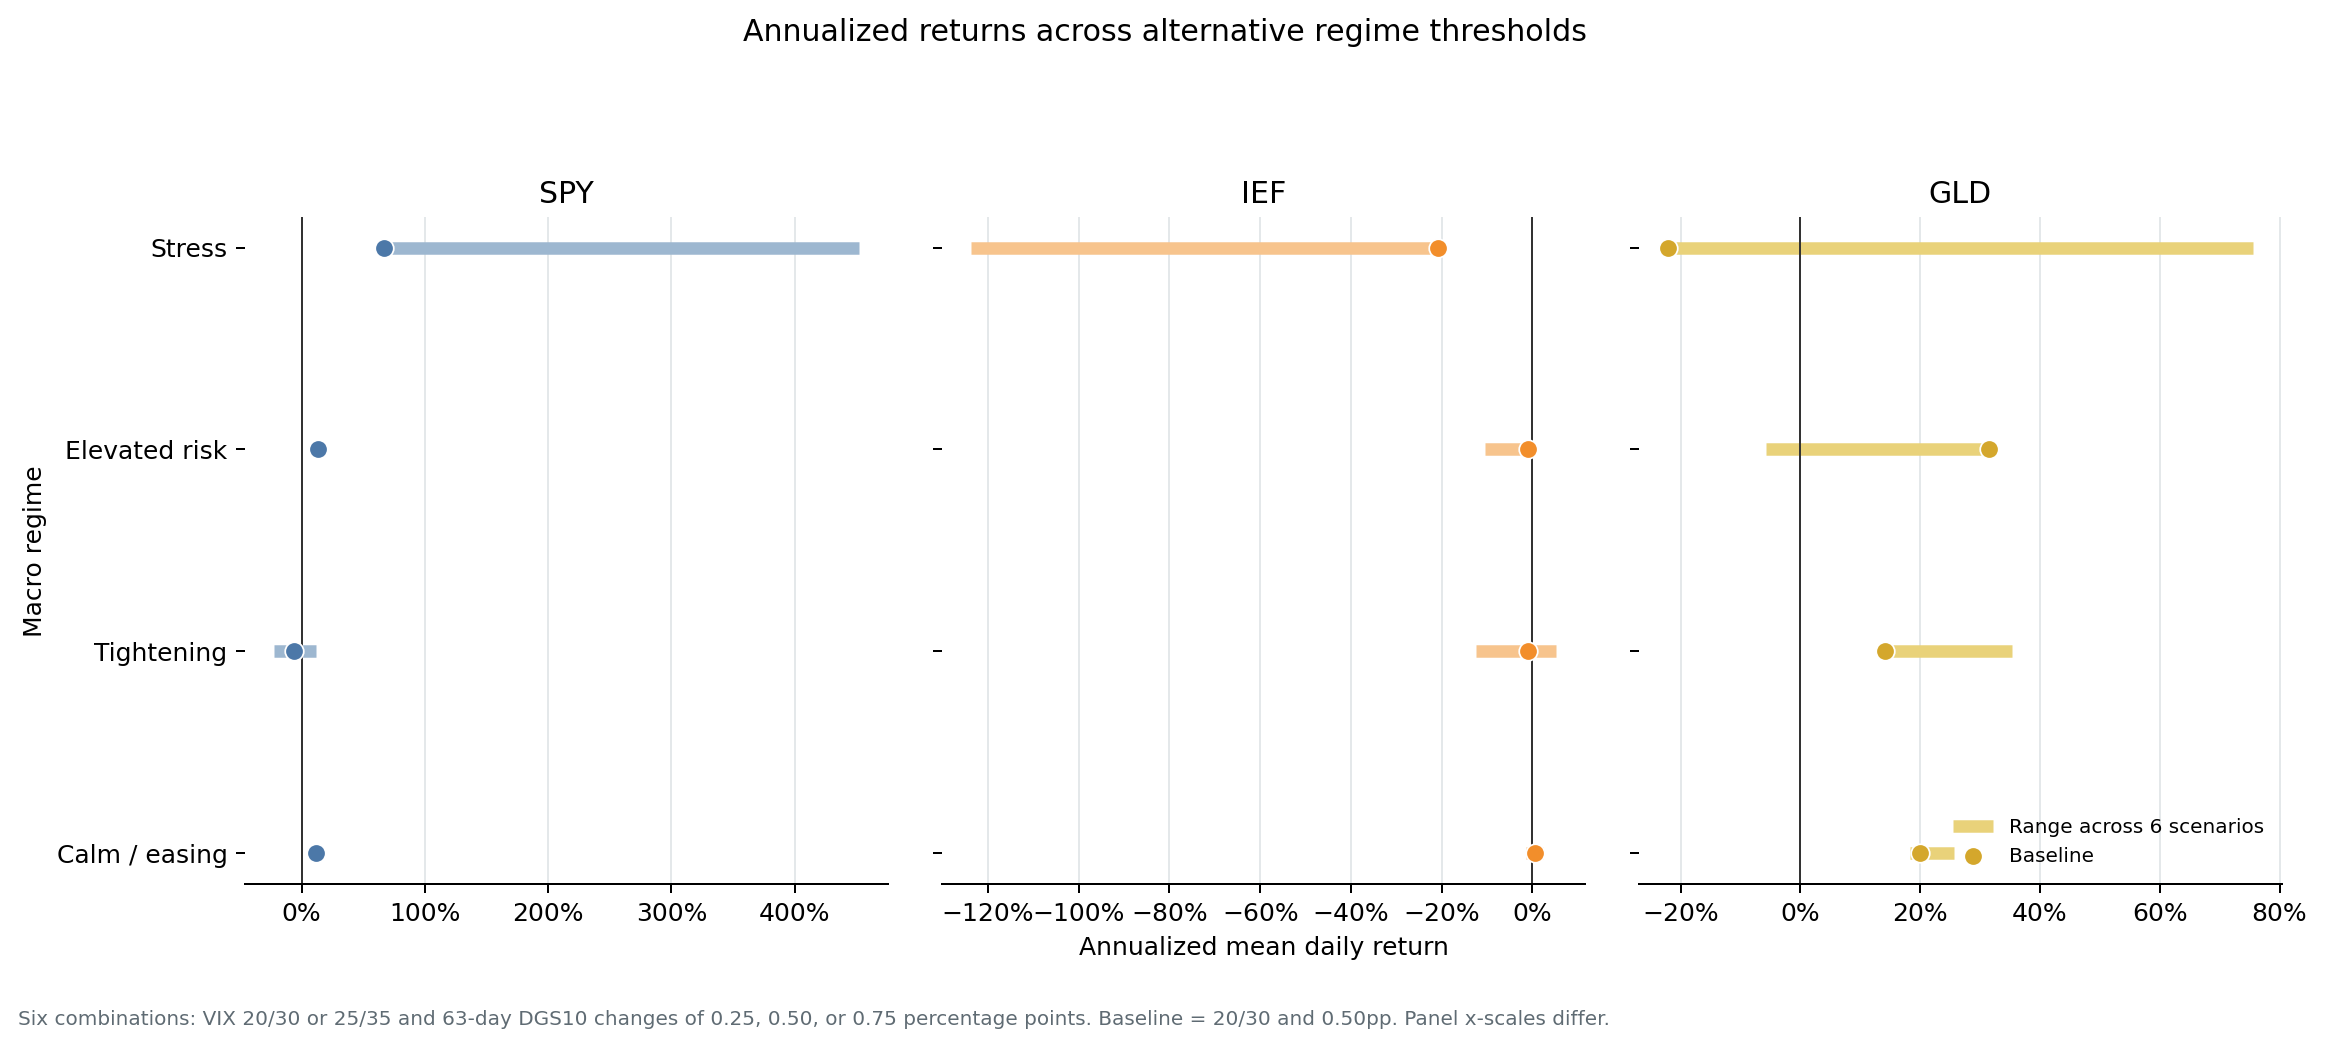

In [3]:
display(Image(filename=str(PROJECT_ROOT / 'outputs/figures/robustness_annualized_return_ranges.png'), width=1050))

### Block-bootstrap intervals

In [4]:
interval_view = results['intervals'].copy()
for column in ['annualized_return', 'ci_2_5', 'ci_97_5']:
    interval_view[column] = interval_view[column].map(lambda value: f'{value:.1%}')
interval_view

,regime,ticker,observations,annualized_return,ci_2_5,ci_97_5,bootstrap_samples,block_size_trading_days,seed
0,Calm / easing,SPY,619,11.3%,-2.4%,24.8%,5000,5,20260715
1,Calm / easing,IEF,619,0.5%,-8.1%,9.0%,5000,5,20260715
2,Calm / easing,GLD,619,20.0%,2.9%,37.1%,5000,5,20260715
3,Tightening,SPY,108,-6.4%,-47.9%,35.9%,5000,5,20260715
4,Tightening,IEF,108,-1.0%,-26.6%,23.8%,5000,5,20260715
5,Tightening,GLD,108,14.0%,-31.5%,58.8%,5000,5,20260715
6,Elevated risk,SPY,322,13.1%,-26.0%,49.1%,5000,5,20260715
7,Elevated risk,IEF,322,-1.1%,-16.5%,15.3%,5000,5,20260715
8,Elevated risk,GLD,322,31.5%,3.6%,59.8%,5000,5,20260715
9,Stress,SPY,62,66.8%,-36.7%,171.5%,5000,5,20260715


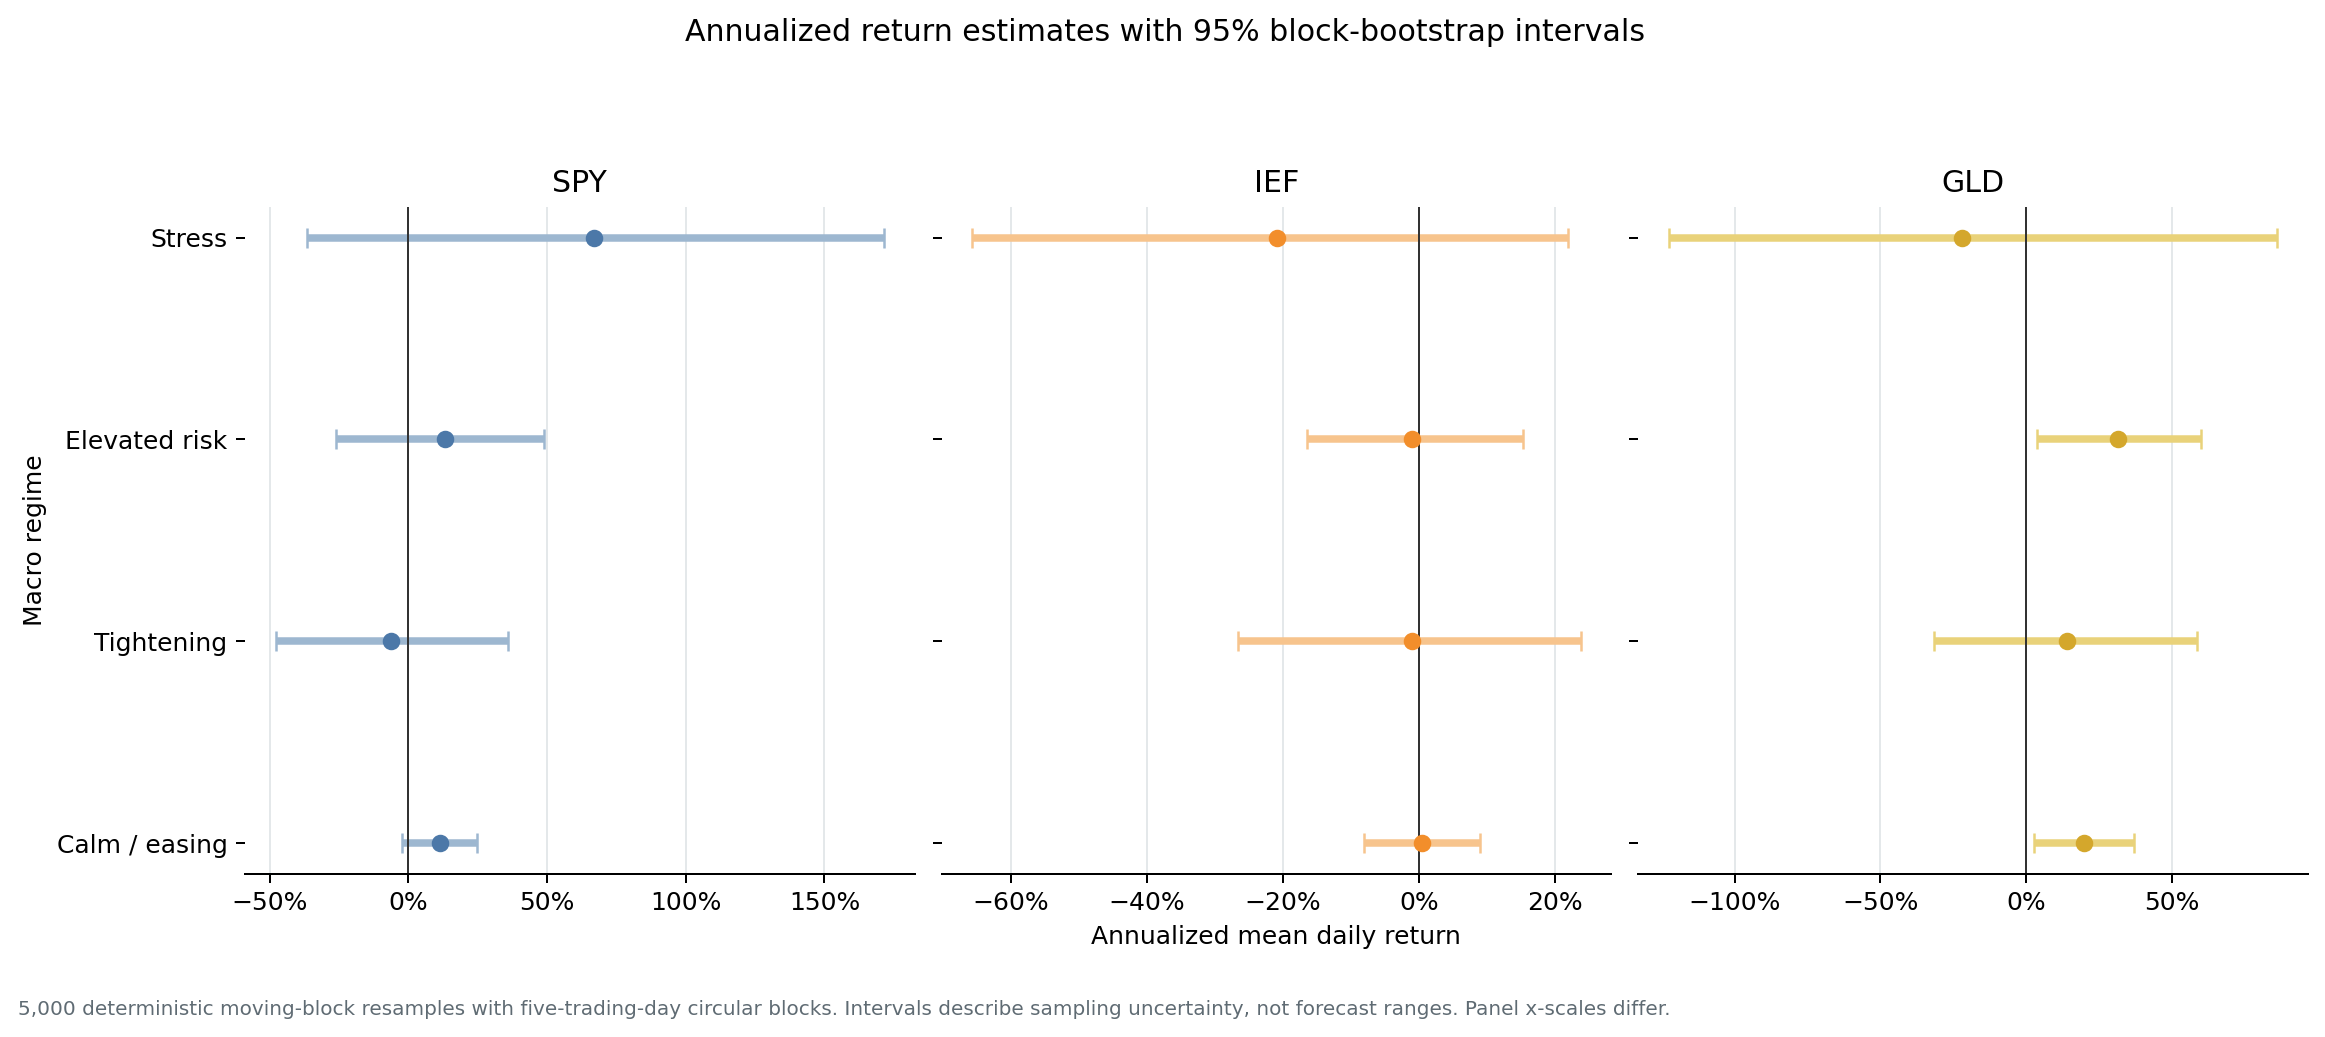

In [5]:
display(Image(filename=str(PROJECT_ROOT / 'outputs/figures/regime_return_bootstrap_intervals.png'), width=1050))

## Takeaways

1. **Keep the Tightening/GLD result, but phrase it as a descriptive association.** It is the most stable relative result across the tested thresholds.
2. **Do not generalize the Elevated-risk or Stress point estimates.** Classification changes materially under higher VIX boundaries, and Stress can shrink to eight observations.
3. **Most return intervals include zero.** The portfolio narrative should emphasize uncertainty and relative patterns rather than treating annualized point estimates as stable premia.
4. **The next statistical upgrade would be episode-level or stationary bootstrapping over a longer history.** The stored macro window begins in 2021, so no resampling method can substitute for missing crisis cycles.